# Ventricular tachyarrhythmias: detection experiments

Companion notebook to the manuscript `paper/PAPER.md`. It runs every experiment the paper reports
and generates its tables and figures, so each result can be regenerated from the data. The
section headings below map onto the paper: dataset build and labelling (paper 3.2 to 3.3), feature
extraction (3.4), dataset composition (4.1), the feature screen (3.5, 4.2), the candidate shootout
(3.6, 4.3), candidate tuning (3.7, 4.4), and flutter versus fibrillation (3.8, 4.5).

The pipeline is classical and deterministic, with no learned classifier. Five candidate detectors
(TCSC, VFLEAK, SPEC, HILB, JEKOVA) are compared on shockable versus non-shockable rhythms and
judged on both discrimination and compute cost. The feature math comes from `vftx`, a validated
reimplementation of the 27 features in Hong's thesis; the dataset and detector code is in `vfta/`.
Records are read through `pxg.cbor`, filtered once each, and sliced into overlapping 8 s and 4 s
windows written as per-record TSVs under `data/s<sec>/`.

## Setup

In [41]:
# This notebook lives at the repo root and should be run from here. pxg is installed in the
# conda env; from the repo root `from vfta import ...` and the data/ and work/ paths resolve.
import numpy as np
import pandas as pd

from vfta import build, labels

%config InlineBackend.figure_format = "retina"

DBS = ['mitdb', 'cudb', 'vfdb', 'ahadb']
WINDOWS = [8.0, 4.0]

## Dataset build (paper 3.2, 3.3)

`cbor record -> record-level filtering -> sliding window -> data/s<sec>/<db>/<rid>.tsv`, parallel
by record. Each record is filtered once (Lynn band-pass plus median baseline), then sliced into
overlapping windows at a 1 s step, at 8 s and 4 s. The build is heavy, so it is run once per
database and window; the cell below is left commented to avoid rerunning by accident.

In [42]:
# for win in WINDOWS:
#     for db in DBS:
#         res = build.build_database(db, window_sec=win, step_sec=1.0, jobs=-1)
#         print(f'{db} s{int(win)}: {len(res)} records, {sum(n for _, n in res)} windows')
#     pass #for
# pass #for

## Labelling windows (paper 3.3)

Each window gets a `Rhythm` from its dominant clean episode (at least 90% of the window, else
`MIX`) and a binary `Shock` label. The clean windows drive the analysis; `MIX` is kept for
evaluation only.

In [43]:
df = labels.load_dataset(['vfdb', 'cudb'], window_sec=8.0, purity=0.9)
print(df['Rhythm'].value_counts())
print(df['Shock'].value_counts())

Rhythm
OTHER    20978
NSR      17375
MIX      14870
VF        5118
VT        4849
VFL        369
Name: count, dtype: int64
Shock
NON      50849
SHOCK    10348
MIX       2362
Name: count, dtype: int64


## Feature extraction (paper 3.4)

`build_record` / `build_database` compute the per-window feature columns with `vftx`. Two families
are excluded by design: QRS features (a signal-only VF/VFL detector cannot depend on a QRS
detector, which must blank during VF/VFL) and the EMD IMF-LZ features (about 2 s/window, too slow
for a real-time target).

The build writes 16 cheap features plus the three JEKOVA absolute-band-pass counts
(`jc1`/`jc2`/`jc3`). The vftx signed counts (`count1`/`count2`/`count3`) stay in the TSV as
reference features but are not analysed, because the signed second count is degenerate; the JEKOVA
candidate uses the absolute-output `jc` counts. Sample entropy is opt-in via `spen=True`. The
signal is converted to millivolts (`int / 200`) and vftx's own frequency filtering is off, since
the record is already filtered.

In [44]:
from vfta import features

print('TSV feature columns:', features.feature_names(jekova=True))
print('analysis features (jc counts as band-pass):', features.screen_features())

# build with features (already wired into build_record/build_database):
# build.build_database('mitdb', window_sec=8.0, jobs=-1)            # 16 vftx features + jc1/2/3
# build.build_database('mitdb', window_sec=8.0, jobs=-1, spen=True) # + sample entropy

TSV feature columns: ['tcsc', 'tci', 'ste', 'mea', 'psr', 'hilb', 'vf_leak', 'm', 'a2', 'fm', 'lz', 'mav', 'count1', 'count2', 'count3', 'amplitude', 'jc1', 'jc2', 'jc3']
analysis features (jc counts as band-pass): ['tcsc', 'tci', 'ste', 'mea', 'psr', 'hilb', 'vf_leak', 'm', 'a2', 'fm', 'lz', 'mav', 'jc1', 'jc2', 'jc3', 'amplitude']


## Dataset composition (paper 4.1)

Load every per-record TSV into one DataFrame per database, at both window lengths, and attach the
Rhythm / Shock targets. The tables below first show the raw picture across all records (including
the full AHADB), then the study dataset applies the benchmark labelling and restricts AHADB to its
8-series ventricular records.

In [45]:
from vfta.segment import LABELS

def load_windows(win):
    return {db: labels.assign_targets(labels.load_database(db, win), win) for db in DBS}
pass #def

def presence_table(data):
    # windows in which each episode type is present (duration > 0), per database
    p = pd.DataFrame({db: {lab: int((df[lab] > 0).sum()) for lab in LABELS}
                      for db, df in data.items()})
    p['ALL'] = p.sum(axis=1)
    p.loc['* windows *'] = {**{db: len(df) for db, df in data.items()},
                            'ALL': sum(len(df) for df in data.values())}
    return p
pass #def

def rhythm_table(data):
    c = pd.DataFrame({db: df['Rhythm'].value_counts() for db, df in data.items()}).fillna(0).astype(int)
    c['ALL'] = c.sum(axis=1)
    return c
pass #def

data = {8.0: load_windows(8.0), 4.0: load_windows(4.0)}
for win, d in data.items():
    print(f'{int(win)} s: {sum(len(df) for df in d.values()):,} windows')
pass #for

8 s: 291,431 windows
4 s: 292,167 windows


### Episode presence: windows containing each rhythm

In [46]:
print('8 s'); display(presence_table(data[8.0]))
print('4 s'); display(presence_table(data[4.0]))

8 s


,mitdb,cudb,vfdb,ahadb,ALL
NSR,65827,1430,18164,0,85421
BGM,3934,0,597,0,4531
TGM,1782,0,0,0,1782
VTH,668,42,5642,0,6352
VFL,182,0,1217,0,1399
VFN,180,4061,0,5549,9790
VFB,0,337,1750,0,2087
AFL,1085,0,0,0,1085
AFB,8488,0,3133,0,11621
EPX,11762,583,18340,0,30685


4 s


,mitdb,cudb,vfdb,ahadb,ALL
NSR,64976,1414,17849,0,84239
BGM,3315,0,553,0,3868
TGM,1473,0,0,0,1473
VTH,448,38,5479,0,5965
VFL,166,0,1022,0,1188
VFN,164,3933,0,5533,9630
VFB,0,337,1722,0,2059
AFL,941,0,0,0,941
AFB,8282,0,3123,0,11405
EPX,11314,575,18033,0,29922


### Rhythm-class composition

In [47]:
print('8 s'); display(rhythm_table(data[8.0]))
print('4 s'); display(rhythm_table(data[4.0]))

8 s


,mitdb,cudb,vfdb,ahadb,ALL
Rhythm,,,,,
MIX,5215,12394,2476,136121,156206
NSR,60557,1118,16257,0,77932
OTHER,20335,522,20456,0,41313
VF,4,3490,1628,5447,10569
VFL,105,0,369,0,474
VT,88,11,4838,0,4937


4 s


,mitdb,cudb,vfdb,ahadb,ALL
Rhythm,,,,,
MIX,3076,12377,1498,136404,153355
NSR,61781,1108,16661,0,79550
OTHER,21419,529,20857,0,42805
VF,2,3646,1659,5480,10787
VFL,124,0,468,0,592
VT,94,15,4969,0,5078


### Study dataset

`load_dataset` applies the benchmark labelling: a window is SHOCK when shockable episodes
(VT/VFL/VF) cover at least 90% of it, NON when no shockable episode is present, and MIX only when a
shockable episode partially straddles it. Unannotated background is therefore non-shockable,
matching how these algorithms are scored over a whole recording. AHADB is kept to its 8-series
records. This is the dataset the screen and the shootout use.

In [48]:
for win in (8.0, 4.0):
    study = labels.load_dataset(DBS, win)
    print(f'{int(win)} s study dataset: {len(study):,} windows')
    display(pd.crosstab(study['DB'], study['Shock']))
pass #for

8 s study dataset: 167,783 windows


Shock,MIX,NON,SHOCK
DB,,,
ahadb,102,12371,5447
cudb,590,13432,3513
mitdb,594,85469,241
vfdb,1772,37417,6835


4 s study dataset: 168,243 windows


Shock,MIX,NON,SHOCK
DB,,,
ahadb,53,12427,5480
cudb,307,13704,3664
mitdb,364,85889,243
vfdb,1127,37889,7096


## Feature screen (paper 3.5, 4.2)

Rank the 16 features by how well each separates shockable from non-shockable windows on the clean
set, by point-biserial correlation, single-feature AUC, and mutual information. A feature-feature
correlation heatmap flags redundancy. Run at 8 s here; the 4 s rerun is below.

In [49]:
from vfta import screen
from vfta.features import screen_features

FEATURES = screen_features()             # 16 features; JEKOVA absolute counts (jc1/2/3) as band-pass
study8 = labels.load_dataset(DBS, 8.0)   # ahadb 8-series, benchmark labels
clean = screen.clean_set(study8)
print(f'clean screen set: {len(clean):,} windows '
      f"({(clean.Shock=='SHOCK').sum():,} SHOCK / {(clean.Shock=='NON').sum():,} NON)")
rank = screen.screen(clean, FEATURES)
rank.round(4)

clean screen set: 164,725 windows (16,036 SHOCK / 148,689 NON)


,feature,pointbiserial,auc_raw,auc,mutual_info
0,jc2,0.7222,0.9855,0.9855,0.2365
1,jc3,-0.7103,0.0151,0.9849,0.2292
2,jc1,0.7842,0.9741,0.9741,0.2223
3,tcsc,0.6227,0.9641,0.9641,0.1850
4,mav,0.6429,0.9639,0.9639,0.1886
5,hilb,0.6139,0.9544,0.9544,0.1833
6,psr,0.6156,0.9439,0.9439,0.1672
7,a2,0.6562,0.9397,0.9397,0.1719
8,vf_leak,-0.6049,0.0758,0.9242,0.1537
9,m,-0.3306,0.0775,0.9225,0.1448


### Ranking: AUC and mutual information

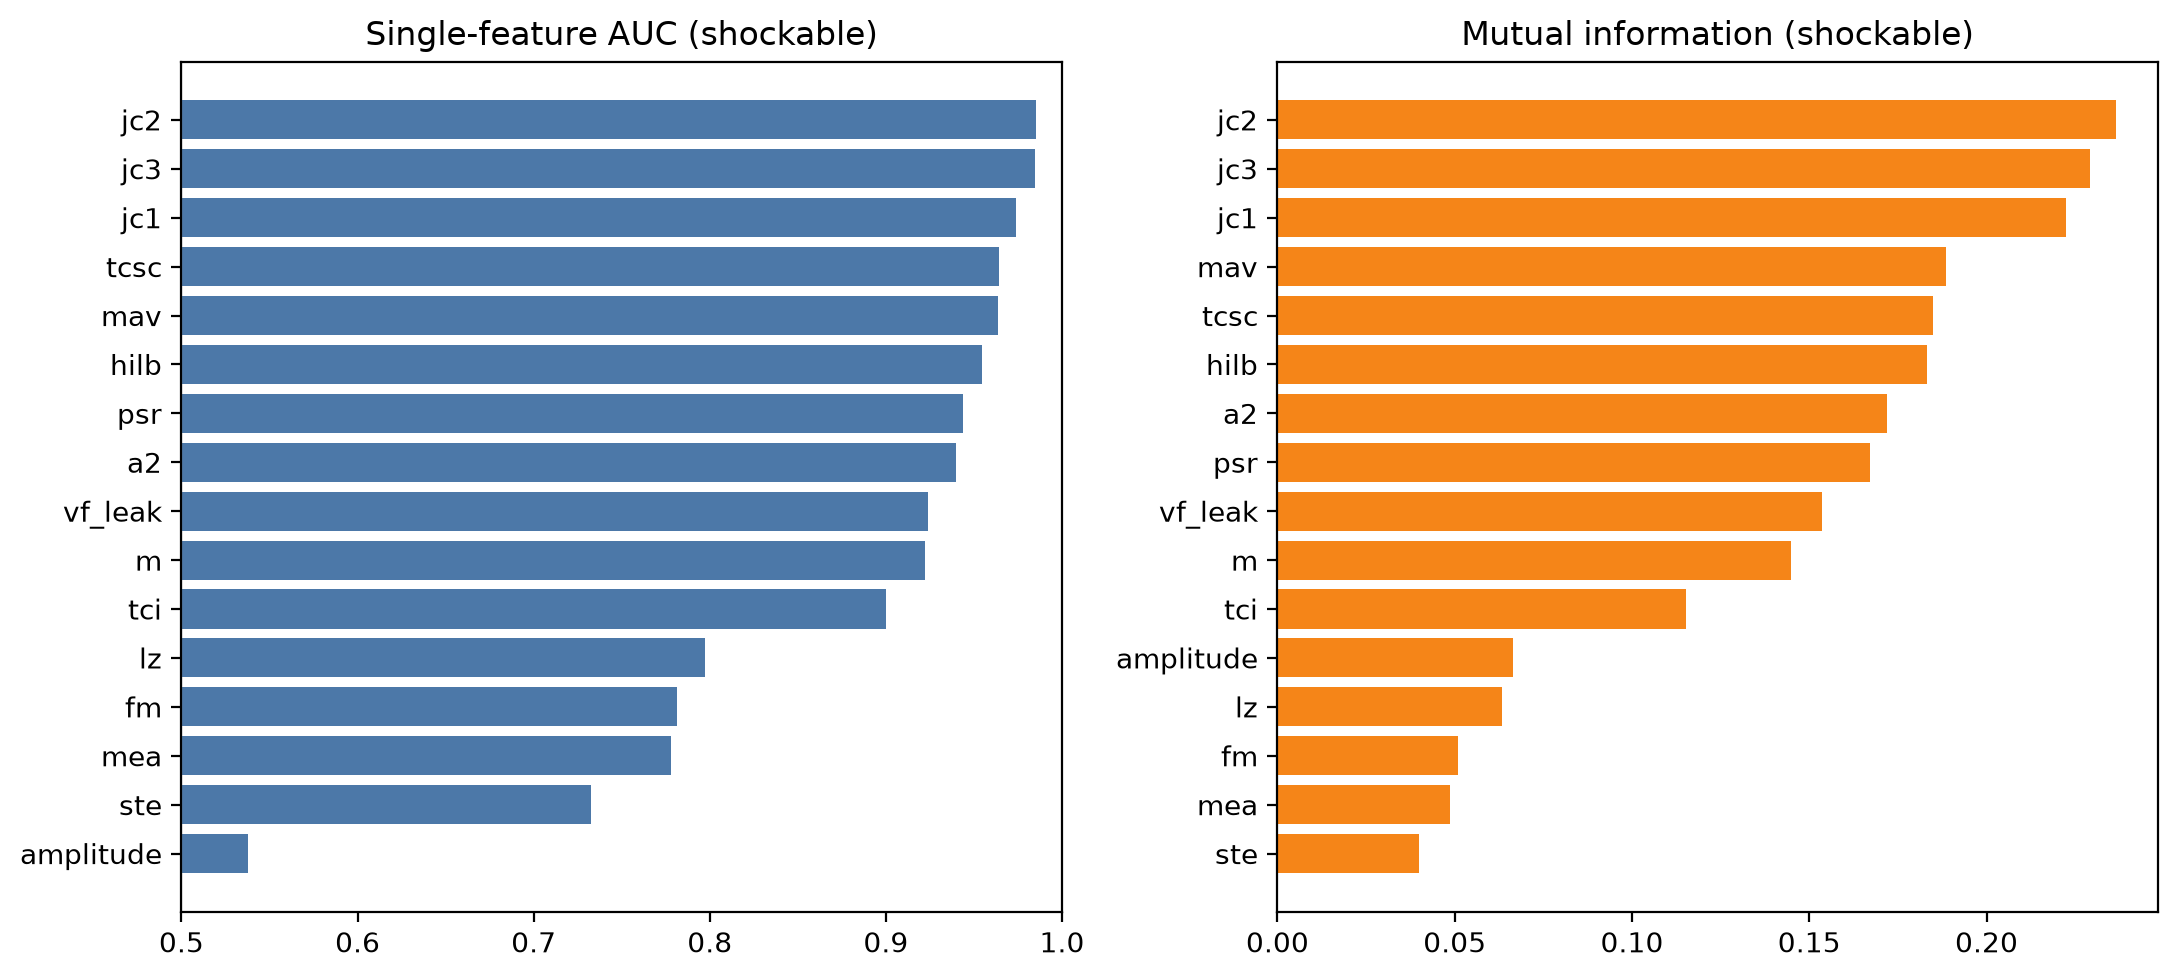

In [50]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
a = rank.sort_values('auc')
ax[0].barh(a['feature'], a['auc'], color='#4c78a8')
ax[0].set_xlim(0.5, 1.0); ax[0].set_title('Single-feature AUC (shockable)')
ax[0].axvline(0.5, color='0.6', lw=0.8)
m = rank.sort_values('mutual_info')
ax[1].barh(m['feature'], m['mutual_info'], color='#f58518')
ax[1].set_title('Mutual information (shockable)')
fig.tight_layout(); plt.show()

### Redundancy: feature-feature correlation

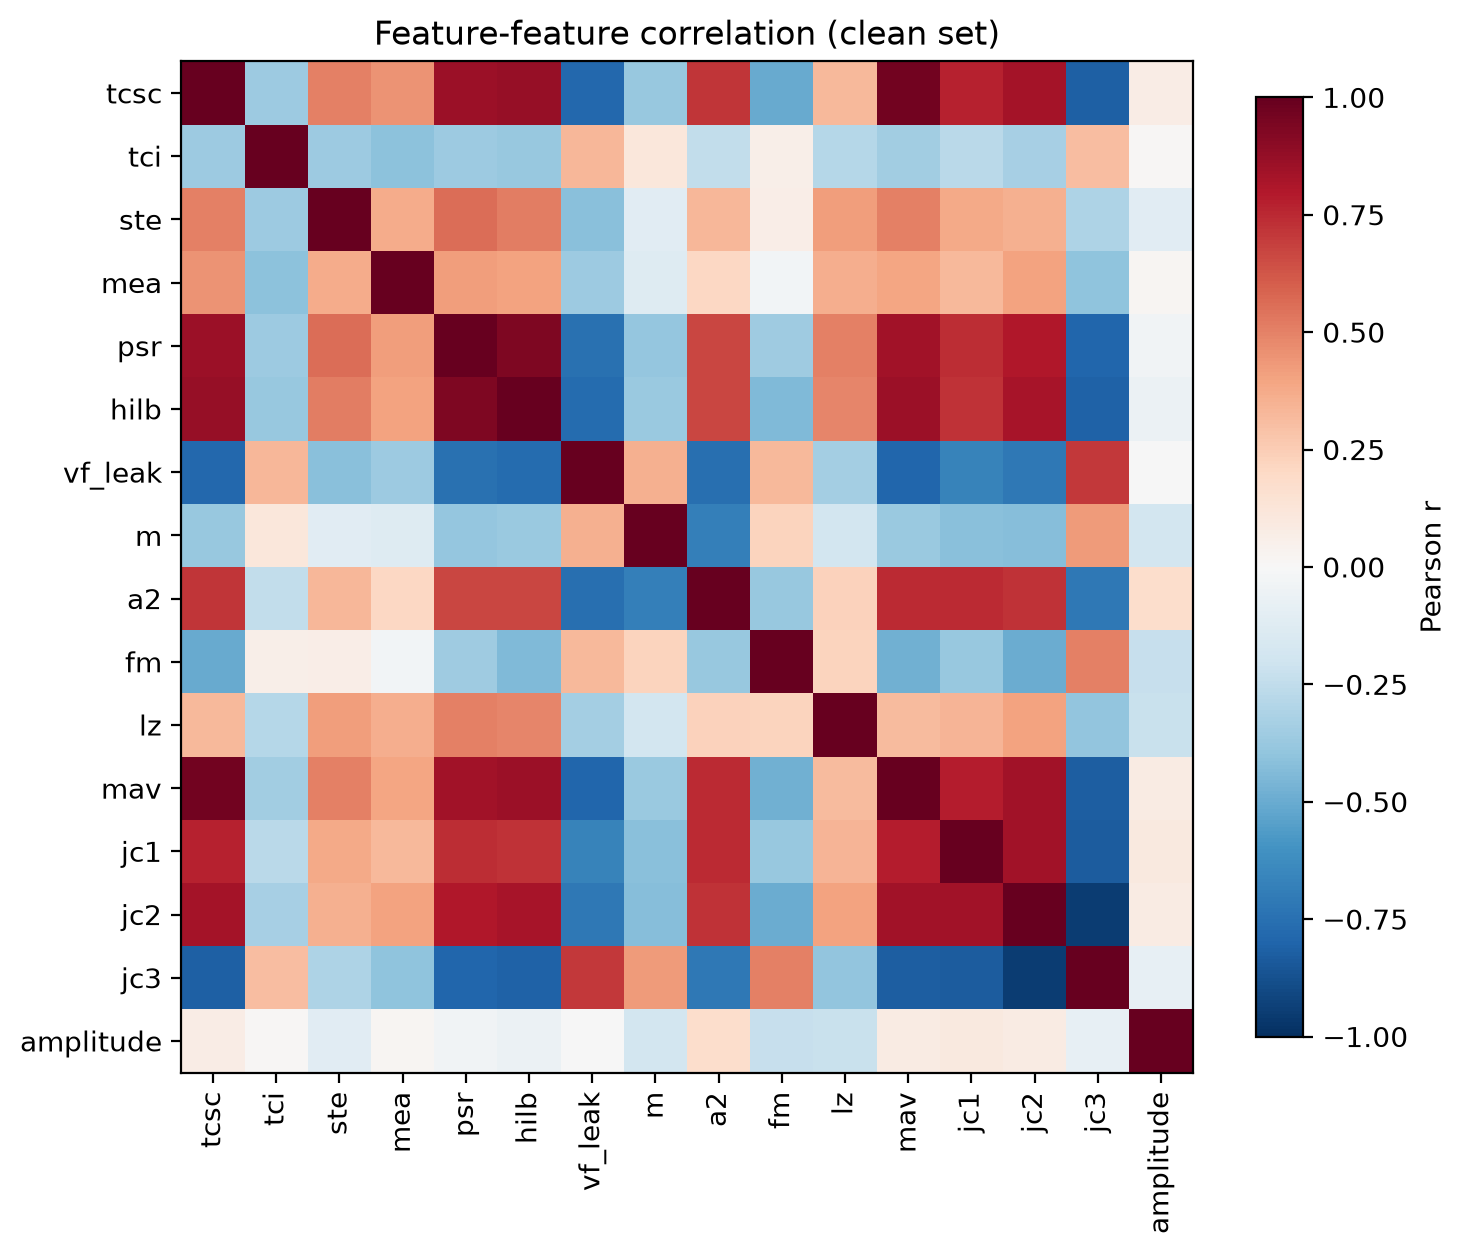

In [51]:
corr = screen.redundancy(clean, FEATURES)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=90)
ax.set_yticks(range(len(FEATURES))); ax.set_yticklabels(FEATURES)
fig.colorbar(im, ax=ax, shrink=0.85, label='Pearson r')
ax.set_title('Feature-feature correlation (clean set)')
fig.tight_layout(); plt.show()

## Candidate shootout (paper 3.6, 4.3)

Five detectors, each a single feature plus a threshold: TCSC (`tcsc`), VFLEAK (`vf_leak`), SPEC
(`m`/`a2`/`fm`), HILB (`hilb`), and JEKOVA (`jc1`/`jc2`/`jc3`). Each is scored by its strongest
(primary) feature: oriented AUC, mutual information, and best F1 at a swept threshold; a
multi-feature detector is represented by its best sub-feature here, with full tuning below.

Alongside discrimination each carries a rough compute cost (ms per 1000 windows), charged at the
primary feature so a detector's shared heavy step (JEKOVA's band-pass, SPEC's spectrum) is counted
once. These are pure-Python, single-thread timings for relative scale only. The winner is argued
from both axes together, since the downstream target is a real-time, embedded detector.

In [52]:
from vfta import shootout

# Each detector = one feature + a threshold. Discrimination is scored on the primary
# (best) feature; compute cost is charged at that same feature (see vfta/shootout.py).
shoot8 = shootout.shootout_table(clean, window_sec=8.0)
print(f"candidate shootout, 8 s (clean set: {(clean.Shock=='SHOCK').sum():,} SHOCK / "
      f"{(clean.Shock=='NON').sum():,} NON)")
shoot8.round(4)

candidate shootout, 8 s (clean set: 16,036 SHOCK / 148,689 NON)


,detector,features,primary,tier,auc,mutual_info,f1,ms_per_kwin
0,JEKOVA,jc1+jc2+jc3,jc2,cheap,0.9855,0.2365,0.8462,1377.9071
1,TCSC,tcsc,tcsc,cheap,0.9641,0.1858,0.7068,95.7335
2,HILB,hilb,hilb,FFT,0.9544,0.1815,0.7230,112.4965
3,SPEC,m+a2+fm,a2,FFT,0.9397,0.1719,0.7187,109.9106
4,VFLEAK,vf_leak,vf_leak,cheap,0.9242,0.1538,0.6919,112.0431


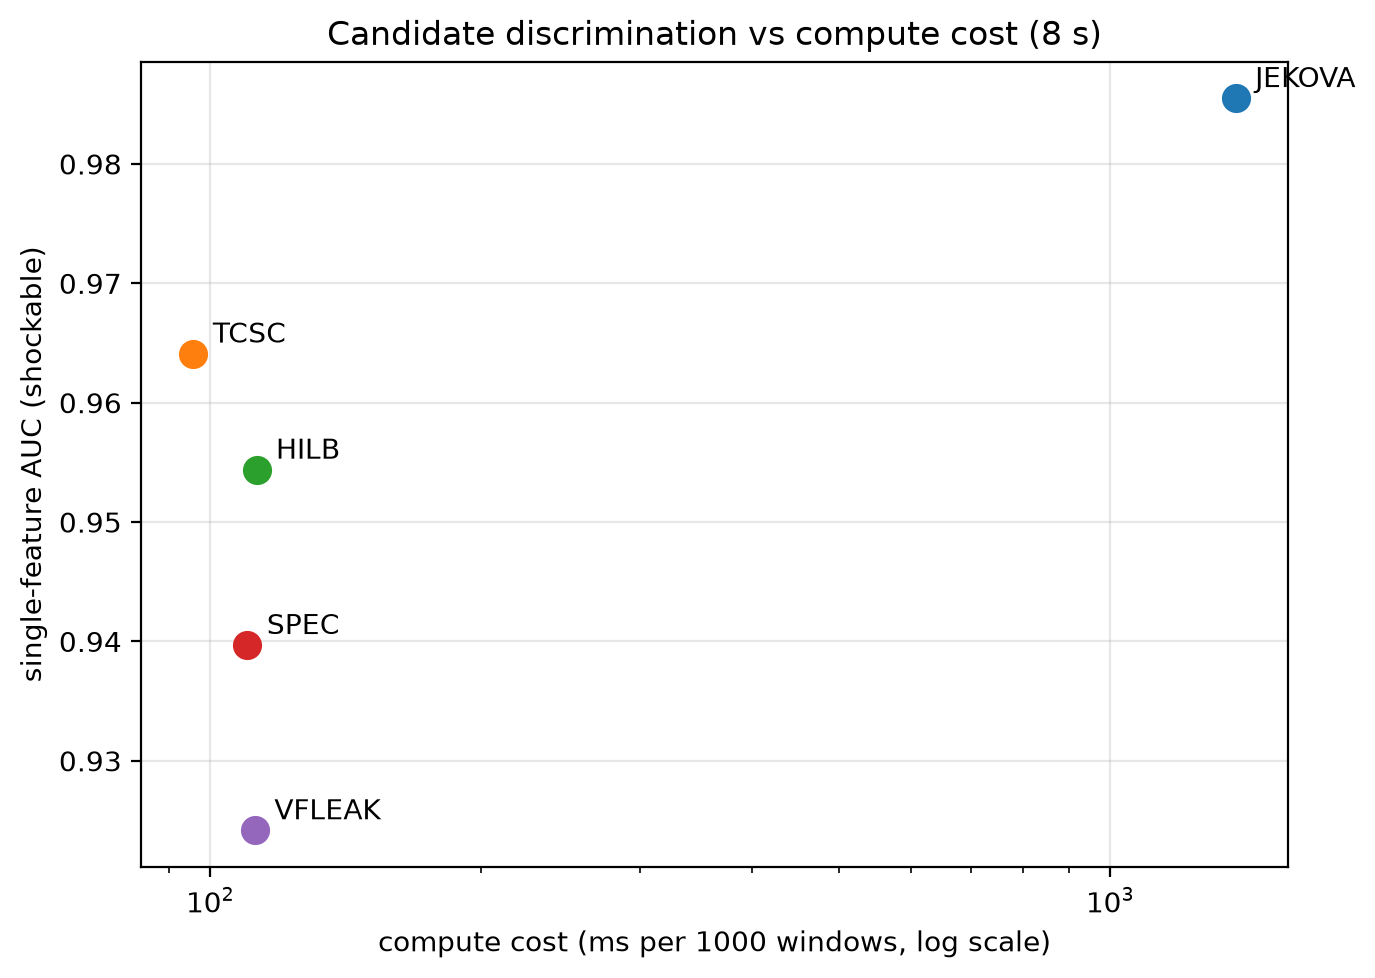

In [53]:
# Discrimination vs compute cost: the winner is argued from both axes.
# Cost is pure-Python ms per 1000 windows on this machine, for relative scale only.
fig, ax = plt.subplots(figsize=(7, 5))
for _, r in shoot8.iterrows():
    ax.scatter(r['ms_per_kwin'], r['auc'], s=90, zorder=3)
    ax.annotate(r['detector'], (r['ms_per_kwin'], r['auc']),
                textcoords='offset points', xytext=(7, 4))
pass #for
ax.set_xscale('log')
ax.set_xlabel('compute cost (ms per 1000 windows, log scale)')
ax.set_ylabel('single-feature AUC (shockable)')
ax.set_title('Candidate discrimination vs compute cost (8 s)')
ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

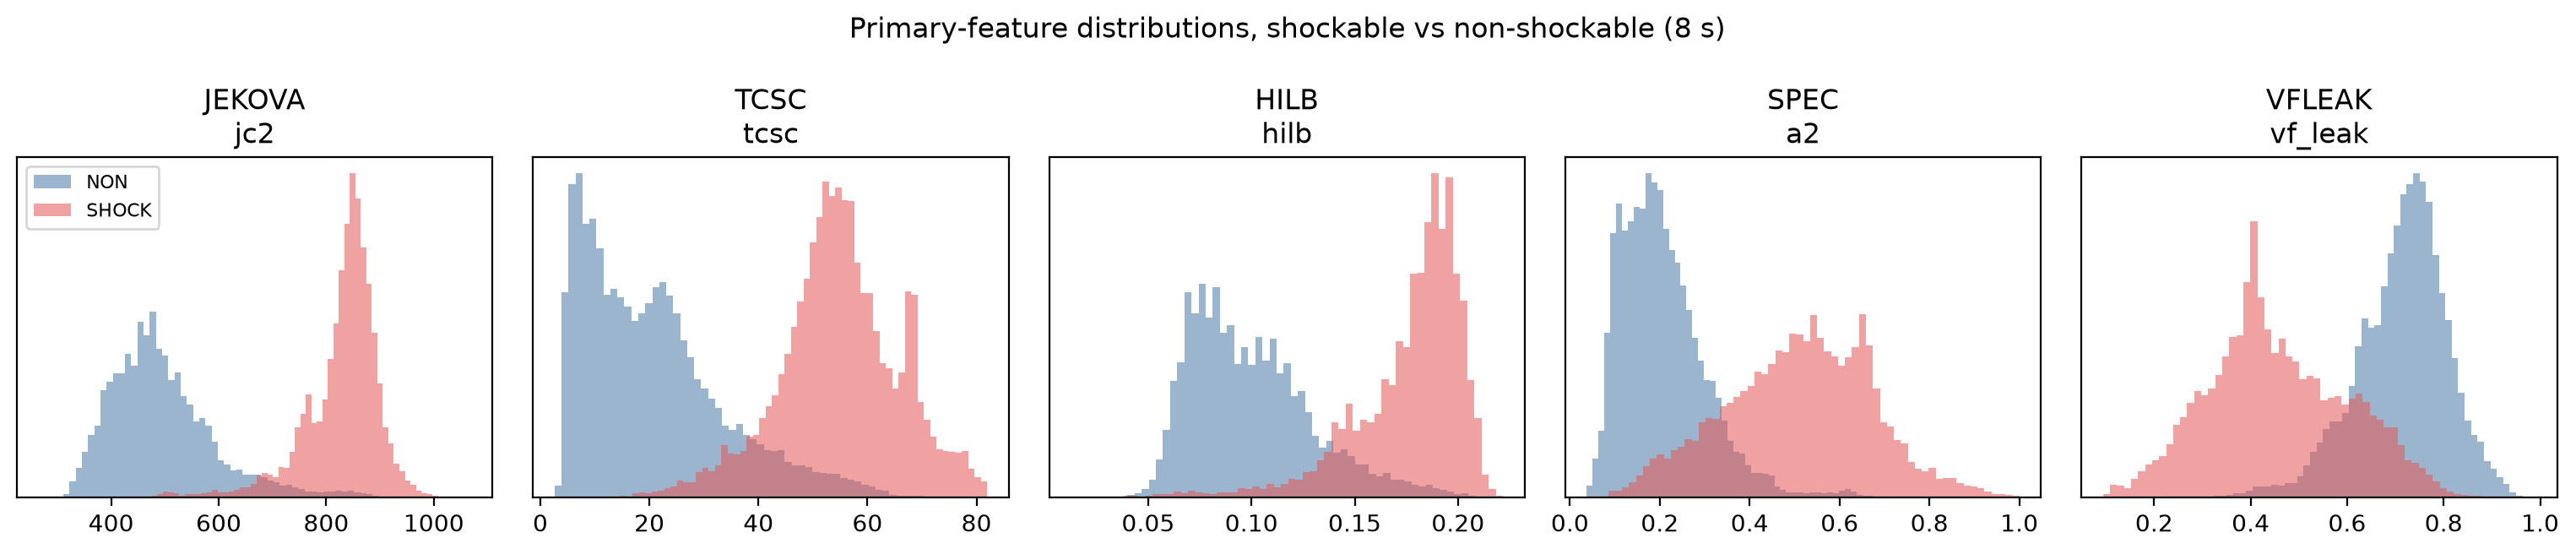

In [54]:
# Primary-feature separation, shockable vs non-shockable (clean set, 8 s).
prim = list(shoot8[['detector', 'primary']].itertuples(index=False, name=None))
fig, ax = plt.subplots(1, len(prim), figsize=(3.1 * len(prim), 3.3))
for k, (det, feat) in enumerate(prim):
    for lab, color in (('NON', '#4c78a8'), ('SHOCK', '#e45756')):
        v = clean.loc[clean['Shock'] == lab, feat].to_numpy(dtype=float)
        ax[k].hist(v, bins=60, density=True, alpha=0.55, color=color, label=lab)
    pass #for
    ax[k].set_title(f'{det}\n{feat}'); ax[k].set_yticks([])
pass #for
ax[0].legend(fontsize=8)
fig.suptitle('Primary-feature distributions, shockable vs non-shockable (8 s)')
fig.tight_layout(); plt.show()

## 4 s rerun (screen and shootout)

The same screen and shootout on the 4 s window, to check the ranking holds on the shorter segment.
The comparison table lines up each detector's 8 s and 4 s discrimination and cost.

In [55]:
study4 = labels.load_dataset(DBS, 4.0)
clean4 = screen.clean_set(study4)
print(f"clean 4 s set: {len(clean4):,} windows "
      f"({(clean4.Shock=='SHOCK').sum():,} SHOCK / {(clean4.Shock=='NON').sum():,} NON)")
rank4 = screen.screen(clean4, FEATURES)
rank4.round(4)

clean 4 s set: 166,392 windows (16,483 SHOCK / 149,909 NON)


,feature,pointbiserial,auc_raw,auc,mutual_info
0,jc2,0.7074,0.9818,0.9818,0.2265
1,jc3,-0.6952,0.0190,0.9810,0.2222
2,jc1,0.7529,0.9631,0.9631,0.2031
3,hilb,0.5725,0.9601,0.9601,0.1854
4,mav,0.6327,0.9562,0.9562,0.1766
5,psr,0.6404,0.9561,0.9561,0.1813
6,tcsc,0.6107,0.9546,0.9546,0.1736
7,a2,0.6518,0.9380,0.9380,0.1709
8,vf_leak,-0.6079,0.0736,0.9264,0.1579
9,m,-0.3275,0.0865,0.9135,0.1387


In [56]:
shoot4 = shootout.shootout_table(clean4, window_sec=4.0)
print(f"candidate shootout, 4 s (clean set: {(clean4.Shock=='SHOCK').sum():,} SHOCK / "
      f"{(clean4.Shock=='NON').sum():,} NON)")
shoot4.round(4)

candidate shootout, 4 s (clean set: 16,483 SHOCK / 149,909 NON)


,detector,features,primary,tier,auc,mutual_info,f1,ms_per_kwin
0,JEKOVA,jc1+jc2+jc3,jc2,cheap,0.9818,0.2269,0.8257,664.5825
1,HILB,hilb,hilb,FFT,0.9601,0.1838,0.7310,95.2062
2,TCSC,tcsc,tcsc,cheap,0.9546,0.1748,0.6810,55.5498
3,SPEC,m+a2+fm,a2,FFT,0.9380,0.1710,0.7067,78.5581
4,VFLEAK,vf_leak,vf_leak,cheap,0.9264,0.1579,0.6799,73.6690


In [57]:
# 8 s vs 4 s discrimination and cost (ms per 1000 windows), per detector.
cmp = shoot8[['detector', 'auc', 'f1', 'ms_per_kwin']].merge(
    shoot4[['detector', 'auc', 'f1', 'ms_per_kwin']],
    on='detector', suffixes=('_8s', '_4s'))
cmp.round(4)

,detector,auc_8s,f1_8s,ms_per_kwin_8s,auc_4s,f1_4s,ms_per_kwin_4s
0,JEKOVA,0.9855,0.8462,1377.9071,0.9818,0.8257,664.5825
1,TCSC,0.9641,0.7068,95.7335,0.9546,0.6810,55.5498
2,HILB,0.9544,0.7230,112.4965,0.9601,0.7310,95.2062
3,SPEC,0.9397,0.7187,109.9106,0.9380,0.7067,78.5581
4,VFLEAK,0.9242,0.6919,112.0431,0.9264,0.6799,73.6690


## Candidate tuning (paper 3.7, 4.4)

Tune the two leading candidates on the clean set, per window length and under the three VFL
configurations (flutter shockable, non-shockable, excluded).

TCSC is a single threshold, swept for best F1 (a ROC sweep). JEKOVA is the published count cascade,
not three independent thresholds: its counts are the absolute-band-pass `jc` counts, normalised to
fractions of the window sample count so one threshold set carries across window lengths, and its
cascade thresholds are grid-searched for best F1. The published-constant cascade is reported as a
baseline. See `vfta/jekova.py` and `vfta/tuning.py`.

In [58]:
from vfta import tuning

CONFIGS = ['shock', 'non', 'excluded']
STUDY = {w: labels.load_dataset(DBS, w) for w in (8.0, 4.0)}   # cached for Phase 4


def operating_points(win):
    rows = []
    for cfg in CONFIGS:
        clean = tuning.binary_set(STUDY[win], win, vfl=cfg)
        mt, _ = tuning.tcsc_tune(clean, 'tcsc')
        pub = tuning.jekova_published(clean, win)
        _, bm, _ = tuning.jekova_tune(clean, win)
        for det, m in [('TCSC', mt), ('JEKOVA (published)', pub), ('JEKOVA (tuned)', bm)]:
            rows.append(dict(window=int(win), vfl=cfg, detector=det,
                             Se=m['se'], Sp=m['sp'], PPV=m['ppv'], F1=m['f1'],
                             Acc=m['acc'], GMean=m['gmean'],
                             TP=m['tp'], FP=m['fp'], TN=m['tn'], FN=m['fn']))
        pass #for
    pass #for
    return pd.DataFrame(rows)
pass #def

ops = pd.concat([operating_points(8.0), operating_points(4.0)], ignore_index=True)
ops.round(4)

,window,vfl,detector,Se,Sp,PPV,F1,Acc,GMean,TP,FP,TN,FN
0,8,shock,TCSC,0.8269,0.9446,0.6166,0.7064,0.9331,0.8838,13260,8244,140445,2776
1,8,shock,JEKOVA (published),0.9730,0.8996,0.5110,0.6701,0.9067,0.9356,15603,14932,133757,433
2,8,shock,JEKOVA (tuned),0.8984,0.9761,0.8018,0.8474,0.9685,0.9364,14407,3561,145128,1629
3,8,non,TCSC,0.8110,0.9404,0.5863,0.6806,0.9281,0.8733,12670,8941,140967,2953
4,8,non,JEKOVA (published),0.9731,0.8924,0.4852,0.6476,0.9000,0.9319,15203,16129,133779,420
5,8,non,JEKOVA (tuned),0.8979,0.9697,0.7557,0.8207,0.9630,0.9331,14028,4535,145373,1595
6,8,excluded,TCSC,0.8084,0.9476,0.6169,0.6998,0.9345,0.8752,12541,7788,140901,2973
7,8,excluded,JEKOVA (published),0.9729,0.8996,0.5027,0.6629,0.9065,0.9355,15094,14932,133757,420
8,8,excluded,JEKOVA (tuned),0.8976,0.9761,0.7964,0.8439,0.9686,0.9360,13925,3561,145128,1589
9,4,shock,TCSC,0.7784,0.9440,0.6047,0.6806,0.9276,0.8572,12830,8388,141521,3653


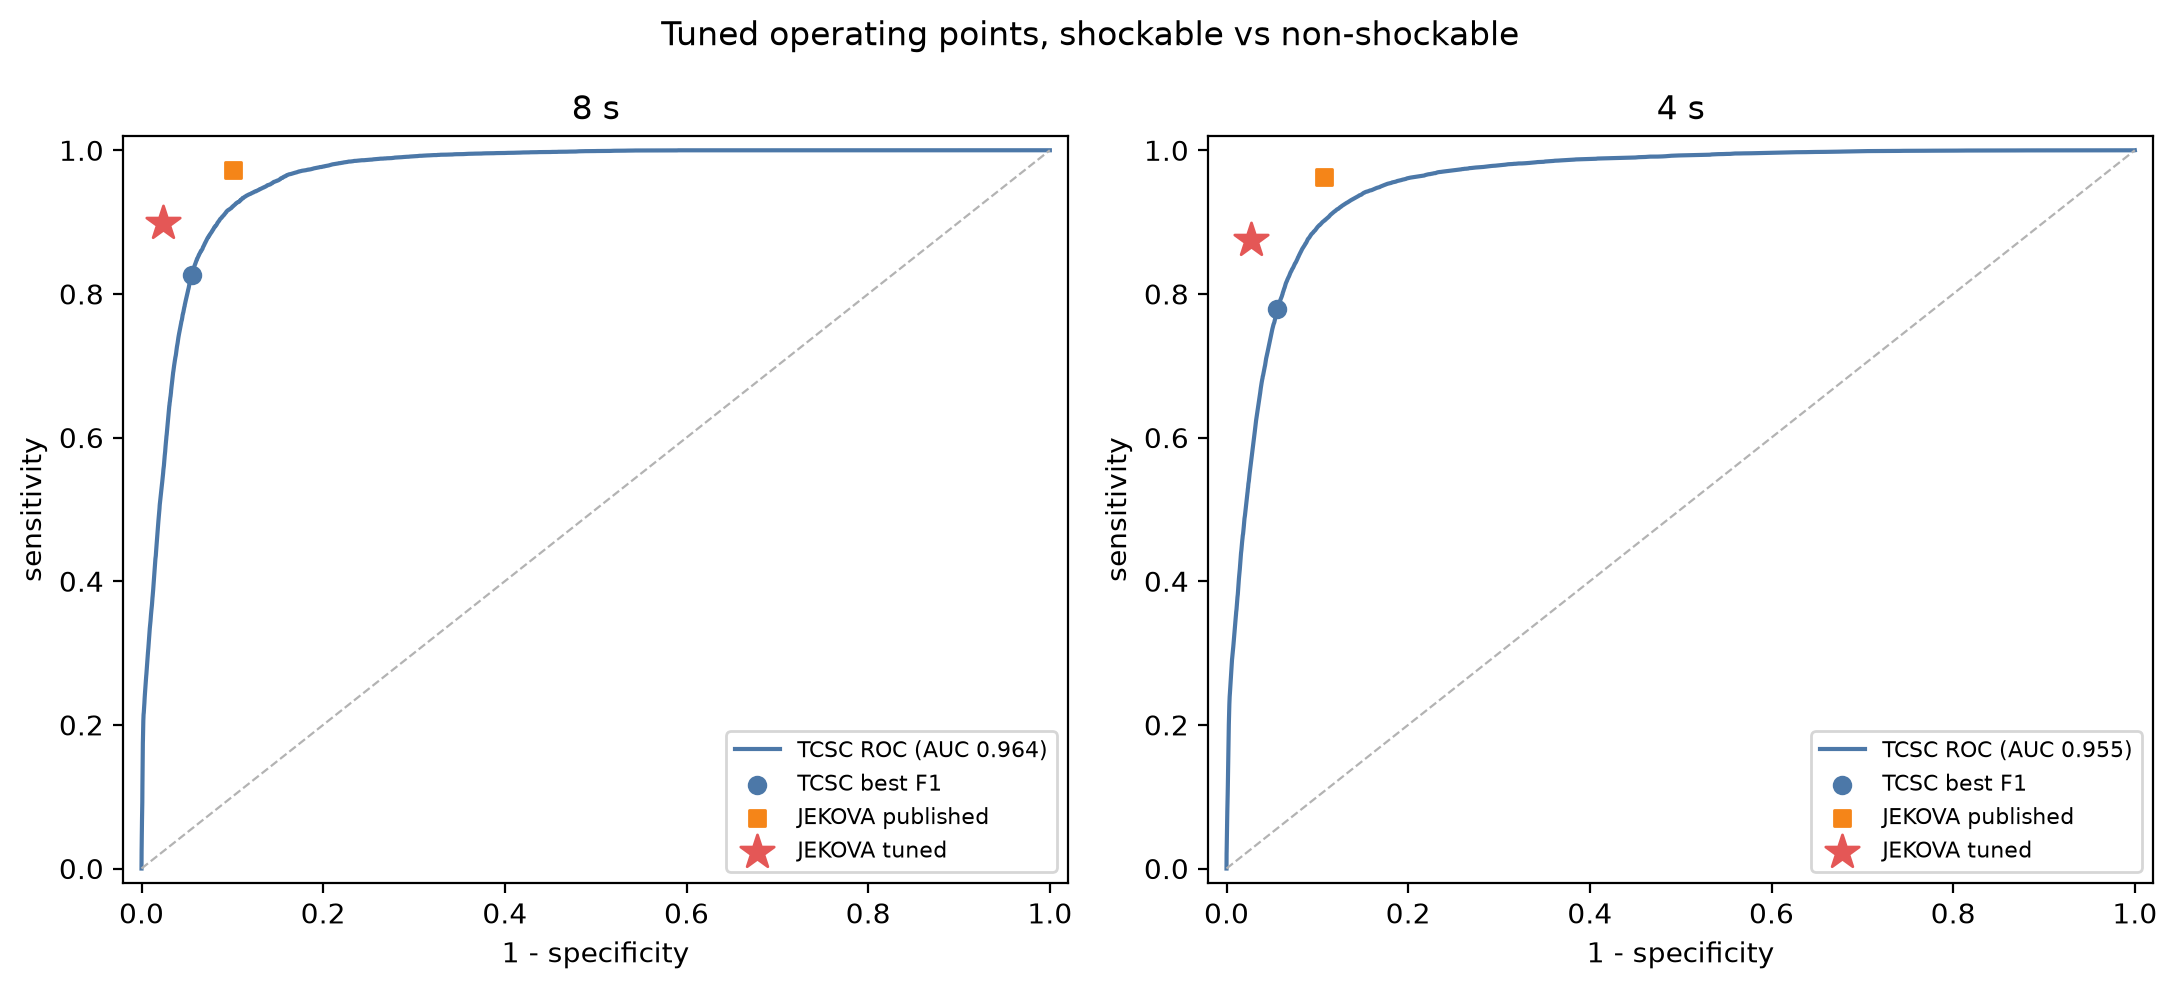

In [59]:
# TCSC ROC curve with the tuned operating points of both detectors (shockable config).
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
for k, win in enumerate((8.0, 4.0)):
    clean = tuning.binary_set(STUDY[win], win, vfl='shock')
    y = clean['y'].to_numpy()
    fpr, tpr, _, auc = tuning.roc(y, clean['tcsc'].to_numpy(dtype=float))
    ax[k].plot(fpr, tpr, color='#4c78a8', lw=1.5, label=f'TCSC ROC (AUC {auc:.3f})')
    ax[k].plot([0, 1], [0, 1], '--', color='0.7', lw=0.8)
    mt, _ = tuning.tcsc_tune(clean, 'tcsc')
    pub = tuning.jekova_published(clean, win)
    _, bm, _ = tuning.jekova_tune(clean, win)
    ax[k].scatter([1 - mt['sp']], [mt['se']], color='#4c78a8', zorder=5, label='TCSC best F1')
    ax[k].scatter([1 - pub['sp']], [pub['se']], color='#f58518', marker='s', zorder=5, label='JEKOVA published')
    ax[k].scatter([1 - bm['sp']], [bm['se']], color='#e45756', marker='*', s=160, zorder=5, label='JEKOVA tuned')
    ax[k].set_title(f'{int(win)} s'); ax[k].set_xlabel('1 - specificity'); ax[k].set_ylabel('sensitivity')
    ax[k].set_xlim(-0.02, 1.02); ax[k].set_ylim(-0.02, 1.02)
    ax[k].legend(fontsize=8, loc='lower right')
pass #for
fig.suptitle('Tuned operating points, shockable vs non-shockable')
fig.tight_layout(); plt.show()

## Flutter vs fibrillation (paper 3.8, 4.5)

Does a cheap feature separate flutter (VFL) from fibrillation (VF)? Using the clean `Rhythm` label
(VFL and VF windows only), each candidate feature is scored by oriented AUC (VF vs VFL). VFL is a
fast, regular, near-sinusoidal oscillation and VF is disorganised, so spectral-concentration and
regularity features should carry the split; the band-pass count is out, since both rhythms share
the absence of 14.6 Hz energy. VFL is rare (a few hundred windows), so this is indicative.

8 s: 474 VFL vs 10569 VF windows (VF vs VFL AUC)
   {'tcsc': 0.735, 'psr': 0.722, 'vf_leak': 0.706, 'hilb': 0.684, 'a2': 0.682, 'm': 0.65, 'jc3': 0.603, 'fm': 0.534}
4 s: 592 VFL vs 10787 VF windows (VF vs VFL AUC)
   {'tcsc': 0.74, 'vf_leak': 0.706, 'psr': 0.697, 'a2': 0.685, 'hilb': 0.636, 'm': 0.623, 'jc3': 0.592, 'fm': 0.506}


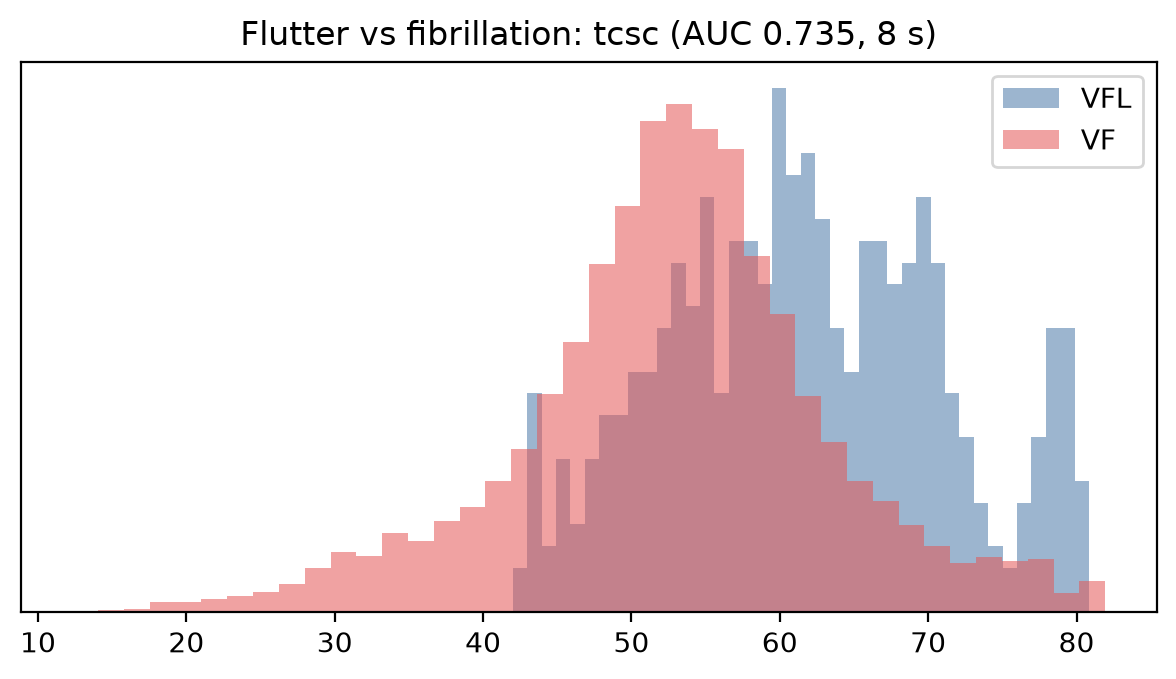

In [60]:
from sklearn.metrics import roc_auc_score

FEATS_VFLVF = ['a2', 'vf_leak', 'psr', 'hilb', 'jc3', 'tcsc', 'fm', 'm']


def vfl_vf_scores(win, feats):
    sub = STUDY[win][STUDY[win]['Rhythm'].isin(['VFL', 'VF'])]
    y = (sub['Rhythm'] == 'VF').astype(int).to_numpy()   # 1 = VF, 0 = VFL
    aucs = {f: max(a, 1 - a) for f in feats for a in [roc_auc_score(y, sub[f].to_numpy(dtype=float))]}
    return sub, y, dict(sorted(aucs.items(), key=lambda kv: -kv[1]))
pass #def

for win in (8.0, 4.0):
    sub, y, aucs = vfl_vf_scores(win, FEATS_VFLVF)
    print(f'{int(win)} s: {(y==0).sum()} VFL vs {(y==1).sum()} VF windows (VF vs VFL AUC)')
    print('  ', {k: round(v, 3) for k, v in aucs.items()})
pass #for

# distribution of the best separating feature at 8 s
sub8, y8, aucs8 = vfl_vf_scores(8.0, FEATS_VFLVF)
best = next(iter(aucs8))
fig, ax = plt.subplots(figsize=(6, 3.5))
for lab, val, color in (('VFL', 0, '#4c78a8'), ('VF', 1, '#e45756')):
    ax.hist(sub8.loc[y8 == val, best].to_numpy(dtype=float), bins=40, density=True,
            alpha=0.55, color=color, label=lab)
pass #for
ax.set_title(f'Flutter vs fibrillation: {best} (AUC {aucs8[best]:.3f}, 8 s)')
ax.legend(); ax.set_yticks([])
fig.tight_layout(); plt.show()